<a href="https://colab.research.google.com/github/Shreyas-2607/6thSem-ML-Lab/blob/main/ML_LAB_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dropping non-numeric columns: ['patient_id']
Original features: 20
Reduced features: 15


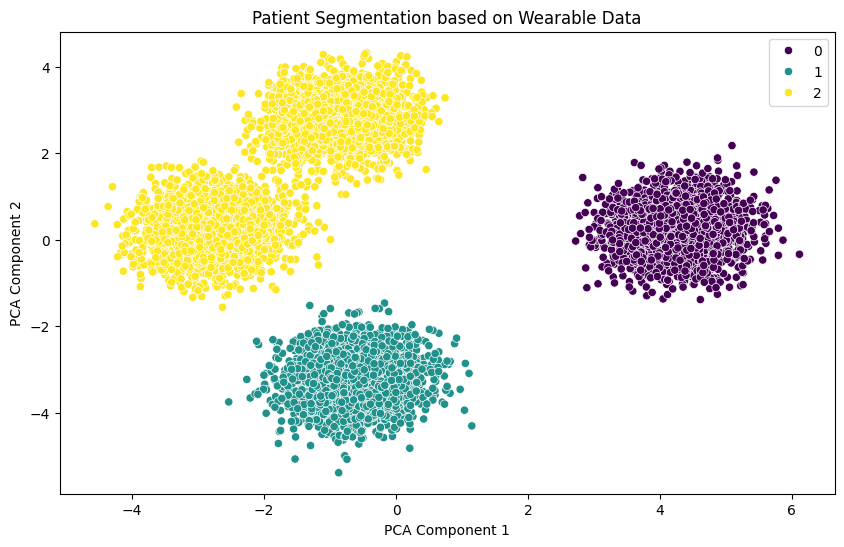

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0  -2.435932  10.928531   2.791178   4.826519  -8.513686  -6.005240   
1  -8.992644  -0.962222 -13.323592   7.794106  -5.629319  -2.582622   
2  -2.994595  -2.162052  12.160186  -7.376829  -3.707112   5.057075   
3   7.574880 -11.114914   0.146845  -3.344159  -6.437541   8.355637   
4  -6.219230   1.652945   7.455083   0.336898  -4.411037  -1.605460   

   feature_7  feature_8  feature_9  feature_10  ...  feature_13  feature_14  \
0  -9.208811   7.808878   2.244146    4.065554  ...    7.596810   -5.595099   
1  -1.843263   2.754043  -0.392068   -4.631934  ...    4.039709    9.053774   
2  -5.196936  10.572810  -8.842692   12.350956  ...   -3.330166    5.853399   
3 -12.761507   0.147110  -3.055103  -10.055192  ...   -8.074997   12.005457   
4  -2.604862   5.173930  -8.642991   10.492449  ...   -9.844332   10.349180   

   feature_15  feature_16  feature_17  feature_18  feature_19  feature_20  \
0   -8.439794   -5.30

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/wearable_patient_data.csv')
X = df.copy()

non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) > 0:
    print(f"Dropping non-numeric columns: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features: {X_scaled.shape[1]}")
print(f"Reduced features: {X_pca.shape[1]}")

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df['cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Patient Segmentation based on Wearable Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

print(df.head())